In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
import warnings
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("FACT_SALES.csv")
df.columns


Index(['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
       'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION'],
      dtype='str')

In [5]:
# Separar WEEK en semana y año
df[['WEEK_NUM', 'YEAR']] = df['WEEK'].str.split('-', expand=True)
df['WEEK_NUM'] = df['WEEK_NUM'].astype(int)
df['YEAR'] = df['YEAR'].astype(int) + 2000  # "22" → 2022

# Crear fecha real (iniciando lunes)
df['FECHA'] = pd.to_datetime(df['YEAR'].astype(str) + df['WEEK_NUM'].astype(str) + '1', format='%G%V%u')

# Ordenar
df = df.sort_values('FECHA').set_index('FECHA')

df.head()


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,WEEK_NUM,YEAR
FECHA,,,,,,,,
2022-01-03,01-22,7501058712813,0.001,0.049,1.000,TOTAL AUTOS AREA 5,1,2022
2022-01-03,01-22,7503002319529,3.512,184.277,6.576,TOTAL AUTOS AREA 1,1,2022
2022-01-03,01-22,7501058792808BP2,0.001,0.023,1.000,TOTAL AUTOS AREA 1,1,2022
2022-01-03,01-22,7501058715883,0.117,24.140,1.887,TOTAL AUTOS AREA 1,1,2022
2022-01-03,01-22,7501058712813,0.009,0.529,2.250,TOTAL AUTOS AREA 1,1,2022


In [6]:
df_weekly = df.groupby(df.index)['TOTAL_UNIT_SALES'].sum().to_frame('VENTAS')
df_weekly.head()


,VENTAS
FECHA,
2022-01-03,5661.824
2022-01-10,5686.147
2022-01-17,4844.874
2022-01-24,4793.584
2022-01-31,5021.274


## 1.Modelo de regresión lineal múltiple

In [7]:
# Copia para regresión
df_reg = df_weekly.copy()

# Variables explicativas de tiempo
df_reg['t'] = np.arange(len(df_reg))
df_reg['mes'] = df_reg.index.month
df_reg['anio'] = df_reg.index.year

X = df_reg[['t', 'mes', 'anio']]
y = df_reg['VENTAS']

# Split simple train/test
split = int(len(df_reg) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predicciones
df_reg['PRED_LR'] = lr.predict(X)

# Métricas en test
y_pred_test_lr = df_reg['PRED_LR'].iloc[split:]

mae_lr = mean_absolute_error(y_test, y_pred_test_lr)
mse_lr = mean_squared_error(y_test, y_pred_test_lr)

print("Regresión Lineal Múltiple")
print("MAE:", mae_lr)
print("MSE:", mse_lr)


Regresión Lineal Múltiple
MAE: 595.2707199143697
MSE: 747979.2308854964


## 2.Gráfico comparativo (train + test)

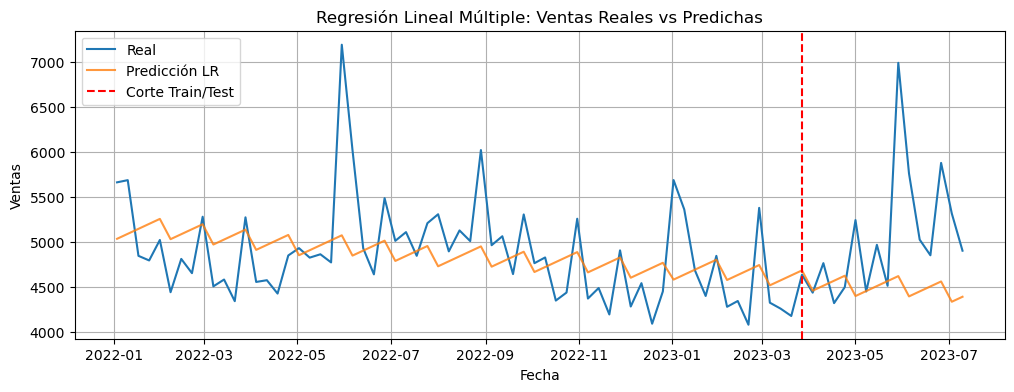

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df_reg.index, df_reg['VENTAS'], label='Real')
plt.plot(df_reg.index, df_reg['PRED_LR'], label='Predicción LR', alpha=0.8)
plt.axvline(df_reg.index[split], color='red', linestyle='--', label='Corte Train/Test')
plt.title('Regresión Lineal Múltiple: Ventas Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


## 3.Modelo de series de tiempo ARIMA/SARIMA

In [13]:
y_ts = df_weekly['VENTAS']

# Conjunto de (p,d,q) para probar
p = d = q = [0, 1, 2]
orders = list(product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in orders:
    try:
        model = SARIMAX(y_ts, order=order, enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False)
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order
            best_model = result
    except:
        continue

print("Mejor orden ARIMA encontrado:", best_order)
print("Mejor AIC:", best_aic)


Mejor orden ARIMA encontrado: (2, 2, 2)
Mejor AIC: 1179.8541697150745


In [14]:
# Ajuste el modelo y validación

result_arima = best_model

# Predicción de la muestra
df_weekly['PRED_ARIMA'] = result_arima.predict(start=df_weekly.index[0],
                                               end=df_weekly.index[-1])

# Corte train/test
y_test_arima = df_weekly['VENTAS'].iloc[split:]
y_pred_test_arima = df_weekly['PRED_ARIMA'].iloc[split:]

mae_arima = mean_absolute_error(y_test_arima, y_pred_test_arima)
mse_arima = mean_squared_error(y_test_arima, y_pred_test_arima)

print("ARIMA")
print("MAE:", mae_arima)
print("MSE:", mse_arima)


ARIMA
MAE: 447.73159843723215
MSE: 487635.9789084773


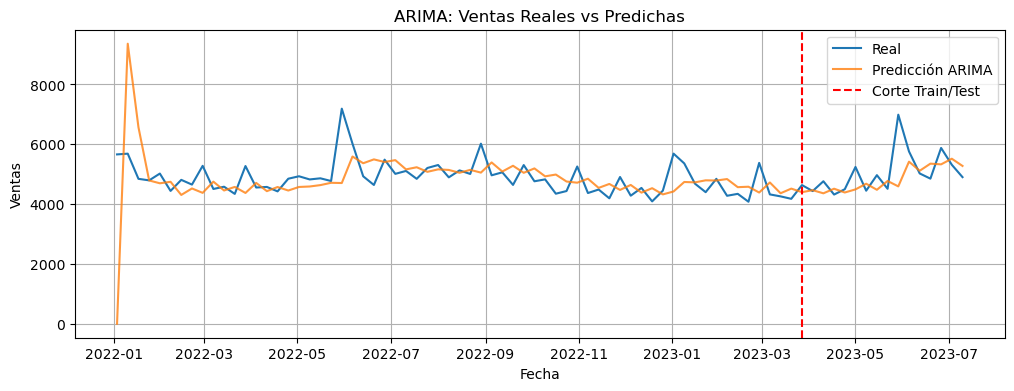

In [15]:
# Gráfico comparativo ARIMA
plt.figure(figsize=(12,4))
plt.plot(df_weekly.index, df_weekly['VENTAS'], label='Real')
plt.plot(df_weekly.index, df_weekly['PRED_ARIMA'], label='Predicción ARIMA', alpha=0.8)
plt.axvline(df_weekly.index[split], color='red', linestyle='--', label='Corte Train/Test')
plt.title('ARIMA: Ventas Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


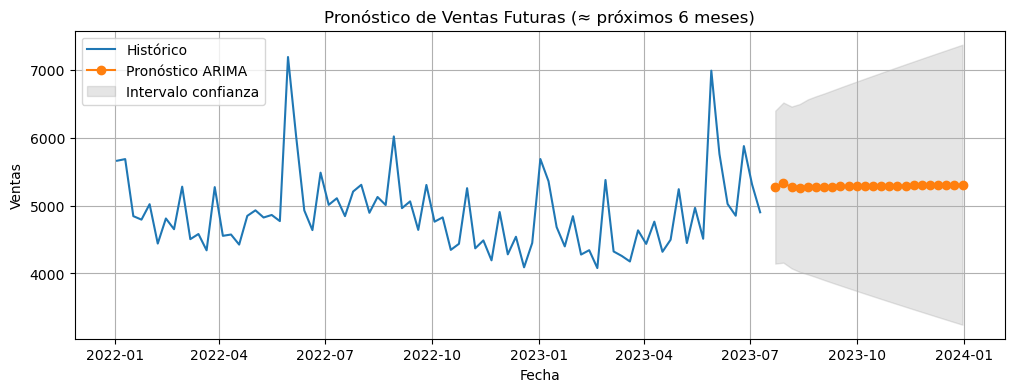

In [16]:
# Predicción de ventas futuras

n_future = 24  # 24 semanas ~ 6 meses

forecast = result_arima.get_forecast(steps=n_future)
pred_future = forecast.predicted_mean
conf_int = forecast.conf_int()

# Índice de fechas futuras
future_index = pd.date_range(start=df_weekly.index[-1] + pd.offsets.Week(1),
                             periods=n_future, freq='W')
pred_future.index = future_index
conf_int.index = future_index

# Gráfico histórico + pronóstico
plt.figure(figsize=(12,4))
plt.plot(df_weekly.index, df_weekly['VENTAS'], label='Histórico')
plt.plot(pred_future.index, pred_future.values, label='Pronóstico ARIMA', marker='o')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='gray', alpha=0.2, label='Intervalo confianza')
plt.title('Pronóstico de Ventas Futuras (≈ próximos 6 meses)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()
